# Notebook 03: Classification Model

**Student Name:** [kalpana]

**Dataset:** concrete_compressive_strength

**Original Target Variable:** [Your Original Numerical Target]

**Binned Target Variable:** [Your Categorical Target - e.g., Low/Medium/High]

**Checkpoint 4 Due:** Feb 22





## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Your binning justification, model selection reasoning, and analysis of the confusion matrix demonstrate your understanding. These reflections are what employers look for—the ability to communicate technical decisions clearly.

---

## Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Sklearn - hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (919, 16)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,water_cement_ratio,total_binder,cement_ratio,water_binder_ratio,aggregate_binder_ratio,fine_coarse_ratio,log_age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0,1.0,0.30,3.177778,0.650000,3.367296
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0,1.0,0.30,3.205556,0.640758,3.367296
2,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03,0.857143,380.0,0.7,0.60,4.215789,0.718884,4.510860
3,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45,0.600000,475.0,0.8,0.48,3.212632,0.637339,3.367296
4,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857143,380.0,0.7,0.60,4.215789,0.718884,3.367296


In [3]:
# Define your original target variable
ORIGINAL_TARGET = 'concrete_compressive_strength'  # <-- UPDATE THIS

print(f"Original Target: {ORIGINAL_TARGET}")
print(f"\nTarget statistics:")
print(df[ORIGINAL_TARGET].describe())

Original Target: concrete_compressive_strength

Target statistics:
count    919.000000
mean      34.432448
std       16.349663
min        2.330000
25%       22.440000
50%       33.190000
75%       44.290000
max       82.600000
Name: concrete_compressive_strength, dtype: float64


## Section 2: Create Binned Target

Convert your regression target into classification categories.

### 2.1 Binning Strategy Justification

**Your approved binning strategy:**

- **Number of categories:** [e.g., 3]
- **Category names:** [e.g., Low, Medium, High]
- **Thresholds:** [e.g., Low: < $50,000, Medium: $50,000-$100,000, High: > $100,000]

**Why this makes sense for your problem:**

[Explain your reasoning - this should match what you submitted to Abishek on Slack]

I distributed target values using binning strategies by low category as 25th percentile, median category, high category 75th percentile.

In [4]:
# View the distribution before binning
print("Target distribution:")
print(f"Min: {df[ORIGINAL_TARGET].min():.2f}")
print(f"25th percentile: {df[ORIGINAL_TARGET].quantile(0.25):.2f}")
print(f"Median: {df[ORIGINAL_TARGET].median():.2f}")
print(f"75th percentile: {df[ORIGINAL_TARGET].quantile(0.75):.2f}")
print(f"Max: {df[ORIGINAL_TARGET].max():.2f}")

Target distribution:
Min: 2.33
25th percentile: 22.44
Median: 33.19
75th percentile: 44.29
Max: 82.60


In [5]:
# TODO: Create your binned target using YOUR approved binning strategy
#
# Steps:
# 1. Define your bin edges (e.g., bins = [min-1, threshold1, threshold2, max+1])
# 2. Define your category labels (e.g., labels = ['Low', 'Medium', 'High'])
# 3. Use pd.cut() to create the binned column
#
# Example:
# bins = [df[ORIGINAL_TARGET].min()-1, 50000, 100000, df[ORIGINAL_TARGET].max()+1]
# labels = ['Low', 'Medium', 'High']
# df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

# YOUR CODE HERE:

# Create binned target using quantile-based thresholds for balanced classes
# Low: below 25th percentile, Medium: 25th–75th percentile, High: above 75th percentile
bins = [df[ORIGINAL_TARGET].min()-1, df[ORIGINAL_TARGET].quantile(0.25), df[ORIGINAL_TARGET].quantile(0.75), df[ORIGINAL_TARGET].max()+1]

# Create binned target using tertile-based thresholds for balanced classes
# Low: below 33rd percentile, Medium: 33rd–66th, High: above 66th percentile
# bins = [df[ORIGINAL_TARGET].min()-1, df[ORIGINAL_TARGET].quantile(0.33), df[ORIGINAL_TARGET].quantile(0.67), df[ORIGINAL_TARGET].max()+1]
labels = ['Low', 'Medium', 'High']

df['target_category'] = pd.cut(df[ORIGINAL_TARGET], bins=bins, labels=labels)

print("\nBinned target distribution:")
print(df['target_category'].value_counts().sort_index())


Binned target distribution:
target_category
Low       231
Medium    458
High      230
Name: count, dtype: int64


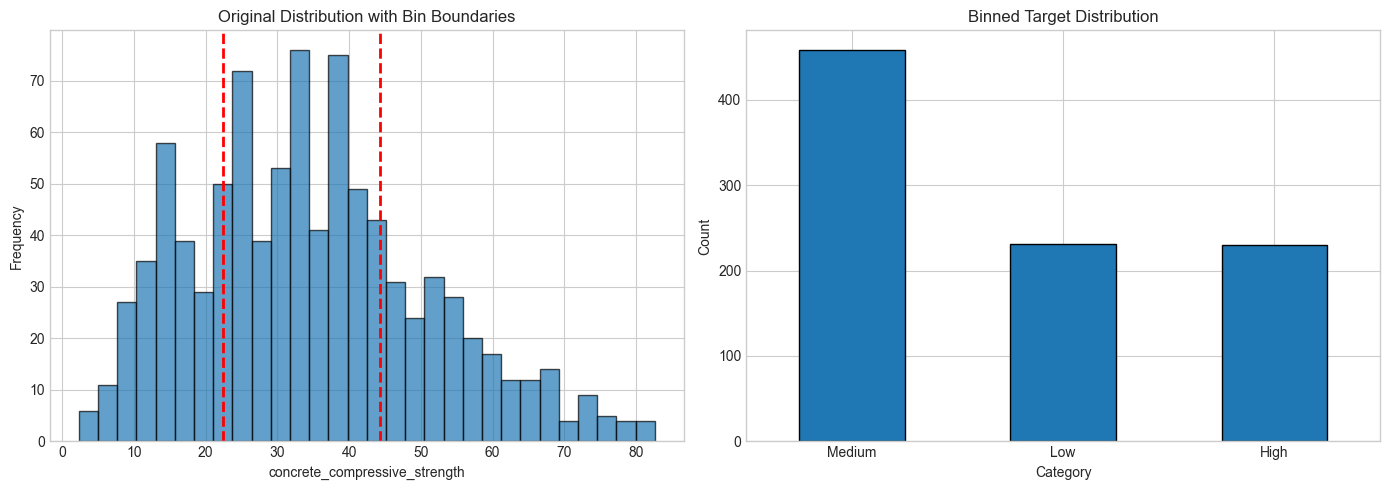

In [6]:
# Visualize the binned distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution with bin lines
axes[0].hist(df[ORIGINAL_TARGET], bins=30, edgecolor='black', alpha=0.7)
for edge in bins[1:-1]:  # Skip first and last (min/max)
    axes[0].axvline(edge, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel(ORIGINAL_TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Distribution with Bin Boundaries')

# Binned category counts
df['target_category'].value_counts().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Binned Target Distribution')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 2.2 Check Class Balance

*Is your binned target reasonably balanced?*

In [7]:
# Check class balance
class_counts = df['target_category'].value_counts()
class_percentages = df['target_category'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
Medium: 458 (49.8%)
Low: 231 (25.1%)
High: 230 (25.0%)

Class balance looks reasonable!


## Section 3: Feature Consistency Check

**Important:** For consistency, you should use the same features for classification as you did for regression. This makes your app simpler (users enter the same inputs for both models) and allows for fair comparison.

If you decide to use different features, provide a strong justification below.

In [8]:
# Load the features you selected in the regression notebook
try:
    regression_features = joblib.load('../models/regression_features.pkl')
    print("Features from Regression Model:")
    print(regression_features)
    print(f"\nNumber of regression features: {len(regression_features)}")
except FileNotFoundError:
    print("Warning: regression_features.pkl not found!")
    print("Make sure you've completed Notebook 02 and saved your regression model first.")
    regression_features = None

Features from Regression Model:
['log_age', 'water_binder_ratio', 'total_binder', 'cement_ratio', 'aggregate_binder_ratio', 'superplasticizer']

Number of regression features: 6


### Feature Selection Decision

**Will you use the same features as your regression model?**

- [ ] **Yes, same features** (Recommended for simpler deployment)
- [ ] **No, different features** (Requires justification below)

**If using different features, justify why:**

[Write your justification here - e.g., "For classification, feature X is less predictive of categories than it was for the continuous target..."]

In [9]:
# DECIDE: Use regression features or define new ones?

# Option A: Use the same features as regression (RECOMMENDED)
if regression_features is not None:
    SELECTED_FEATURES = regression_features
    print("Using same features as regression model.")
else:
    # Option B: Define your own features (if regression not done yet)
    SELECTED_FEATURES = [
        # 'feature1',
        # 'feature2',
        # 'feature3',
        # etc.
    ]
    print("Defining features manually.")

print(f"\nSelected features for classification ({len(SELECTED_FEATURES)}):")
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i}. {f}")

Using same features as regression model.

Selected features for classification (6):
  1. log_age
  2. water_binder_ratio
  3. total_binder
  4. cement_ratio
  5. aggregate_binder_ratio
  6. superplasticizer


## Section 4: Prepare Features and Target

In [10]:
# Create feature matrix using SELECTED features
X = df[SELECTED_FEATURES].copy()
y = df['target_category']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (919, 6)
Target shape: (919,)

Features used: ['log_age', 'water_binder_ratio', 'total_binder', 'cement_ratio', 'aggregate_binder_ratio', 'superplasticizer']

Target classes: ['High', 'Medium', 'Low']


### 4.1 Label Encoding

Many sklearn models require numeric targets. Use LabelEncoder to convert category names to numbers.

In [11]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
# 2. Fit and transform y to create y_encoded
#
# Hint: label_encoder.fit_transform(y)

# YOUR CODE HERE:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Encoded target classes: {label_encoder.classes_}")

Encoded target classes: ['High' 'Low' 'Medium']


In [12]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
High -> 0
Low -> 1
Medium -> 2


## Section 5: Train-Test Split

For classification, we use **stratified** splitting to ensure each class is proportionally represented in both train and test sets.

In [13]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (735, 6), (735,)
Test set shape: (184, 6), (184,)


In [14]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c} ({c/len(y_train)*100:.1f}%)")

Training set: 735 samples
Test set: 184 samples

Training class distribution:
  High: 184 (25.0%)
  Low: 185 (25.2%)
  Medium: 366 (49.8%)


## Section 6: Feature Scaling

In [15]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train
# 3. transform (only!) on X_test
#
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training features shape: {X_train_scaled.shape}")
print(f"Scaled test features shape: {X_test_scaled.shape}")

Scaled training features shape: (735, 6)
Scaled test features shape: (184, 6)


In [16]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 6 features.


In [17]:
# Verify scaling (run this to check)
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std().mean():.4f}")
print(f"Test features means: {X_test_scaled.mean().mean():.4f}")
print(f"Test features stds: {X_test_scaled.std().mean():.4f}")


Scaled feature means (should be ~0): -0.0000
Scaled feature stds (should be ~1): 1.0007
Test features means: -0.0170
Test features stds: 0.9992


## Section 7: Baseline Model

In [18]:
# This helper function evaluates any classifier - you'll use it throughout
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    """Train classifier and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision (weighted)': precision_score(y_test, y_test_pred, average='weighted'),
        'Recall (weighted)': recall_score(y_test, y_test_pred, average='weighted'),
        'F1 (weighted)': f1_score(y_test, y_test_pred, average='weighted')
    }
    
    return results, model, y_test_pred

In [19]:
# TODO: Create and evaluate a baseline Logistic Regression model
#
# Create LogisticRegression(random_state=42, max_iter=1000)
# Use evaluate_classifier() to train and evaluate

# YOUR CODE HERE:

# baseline_model = ...
# baseline_results, baseline_trained, baseline_preds = evaluate_classifier(...)
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_results, baseline_trained, baseline_preds = evaluate_classifier(
    baseline_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression (Baseline)"
)
print("Baseline model evaluated successfully!")
print(f"Baseline results: {baseline_results}")

Baseline model evaluated successfully!
Baseline results: {'Model': 'Logistic Regression (Baseline)', 'Train Accuracy': 0.8149659863945579, 'Test Accuracy': 0.8260869565217391, 'Precision (weighted)': 0.8299856527977043, 'Recall (weighted)': 0.8260869565217391, 'F1 (weighted)': 0.8255717502073705}


In [20]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Logistic Regression")
print("=" * 50)
print(f"Train Accuracy: {baseline_results['Train Accuracy']:.4f}")
print(f"Test Accuracy:  {baseline_results['Test Accuracy']:.4f}")
print(f"F1 Score:       {baseline_results['F1 (weighted)']:.4f}")

BASELINE MODEL: Logistic Regression
Train Accuracy: 0.8150
Test Accuracy:  0.8261
F1 Score:       0.8256


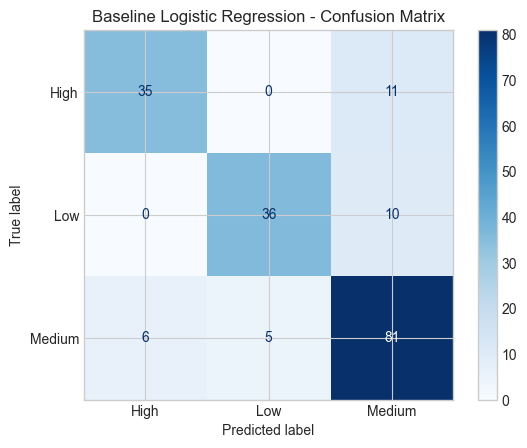

In [21]:
# TODO: Create and display the confusion matrix for baseline
#
# Steps:
# 1. Use confusion_matrix(y_test, baseline_preds) to create the matrix
# 2. Use ConfusionMatrixDisplay to visualize it
#
# Hint: ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# YOUR CODE HERE:
cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

### Understanding the Confusion Matrix

The confusion matrix shows where your model gets predictions right and wrong:

- **Diagonal cells (top-left to bottom-right):** Correct predictions
- **Off-diagonal cells:** Misclassifications
- **Row:** What the actual class was
- **Column:** What the model predicted

**How to read it:** 
- If a row has many values spread across columns, that class is often confused with others
- If a column has many values from different rows, the model is predicting that class too often

**Example interpretation:**
- "20 Low samples were correctly predicted as Low"
- "5 Medium samples were incorrectly predicted as High"

### Baseline Interpretation

*Analyze your baseline results:*

**Questions to answer:**
- How well does the baseline perform?
- Which classes are easiest/hardest to predict (look at the diagonal)?
- Where does the model get confused (look at off-diagonal cells)?
- Is there overfitting (train vs test accuracy gap)?

**Your interpretation:**

[Write your interpretation here - be specific about which categories the model struggles with]

## Section 8: Cross-Validation

Cross-validation gives us a more robust estimate of model performance by training on different portions of the data.

In [22]:
# Cross-validation for key models — using regularized params to avoid overfitting
print("5-Fold Cross-Validation Results")
print("=" * 50)

models_to_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=7,
        min_samples_leaf=5, min_samples_split=10,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=4,
        learning_rate=0.05, min_samples_leaf=5,
        random_state=42
    )
}

cv_results = []
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Std': scores.std()
    })
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)
cv_df

5-Fold Cross-Validation Results
Logistic Regression: 0.8150 (+/- 0.0533)
Random Forest: 0.8272 (+/- 0.0686)
Gradient Boosting: 0.8435 (+/- 0.0413)


,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.814966,0.026661
1,Random Forest,0.827211,0.034312
2,Gradient Boosting,0.843537,0.020634


### Cross-Validation Interpretation

*What does the cross-validation tell you?*

- Which model is most consistent (lowest std)?
- Does the ranking change from the single train/test split?

**Your interpretation:**

[Write your interpretation here]

## Section 9: Model Iteration

In [23]:
# Store all results
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Logistic Regression (Baseline)': baseline_trained
}

### Model 2: Decision Tree

In [24]:
# TODO: Create and evaluate a Decision Tree classifier
#
# Create DecisionTreeClassifier(max_depth=10, random_state=42)
# Use evaluate_classifier() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_results, dt_trained, dt_preds = evaluate_classifier(
    dt_model, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree"
)
all_results.append(dt_results)
trained_models['Decision Tree'] = dt_trained

print(f"Decision Tree - Train: {dt_results['Train Accuracy']:.4f}, Test: {dt_results['Test Accuracy']:.4f}, F1: {dt_results['F1 (weighted)']:.4f}")

Decision Tree - Train: 0.9007, Test: 0.8261, F1: 0.8262


### Model 3: Random Forest

In [25]:
# TODO: Create and evaluate a Random Forest classifier
#
# Create RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_results, rf_trained, rf_preds = evaluate_classifier(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest"
)
all_results.append(rf_results)
trained_models['Random Forest'] = rf_trained

print(f"Random Forest - Train: {rf_results['Train Accuracy']:.4f}, Test: {rf_results['Test Accuracy']:.4f}, F1: {rf_results['F1 (weighted)']:.4f}")

Random Forest - Train: 0.8925, Test: 0.8533, F1: 0.8517


### Model 4: K-Nearest Neighbors

In [26]:
# TODO: Create and evaluate a KNN classifier
#
# Create KNeighborsClassifier(n_neighbors=5)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_results, knn_trained, knn_preds = evaluate_classifier(
    knn_model, X_train_scaled, X_test_scaled, y_train, y_test, "KNN"
)
all_results.append(knn_results)
trained_models['KNN'] = knn_trained

# Print results
print(f"KNN - Train Accuracy: {knn_results['Train Accuracy']:.4f}, Test Accuracy: {knn_results['Test Accuracy']:.4f}, F1: {knn_results['F1 (weighted)']:.4f}")

KNN - Train Accuracy: 0.8993, Test Accuracy: 0.8696, F1: 0.8693


### Model 5: Gradient Boosting

In [27]:
# TODO: Create and evaluate a Gradient Boosting classifier
#
# Create GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
# Use evaluate_classifier()
# Add to all_results and trained_models

# YOUR CODE HERE:
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_results, gb_trained, gb_preds = evaluate_classifier(
    gb_model, X_train_scaled, X_test_scaled, y_train, y_test, "Gradient Boosting"
)
all_results.append(gb_results)
trained_models['Gradient Boosting'] = gb_trained

print(f"Gradient Boosting - Train: {gb_results['Train Accuracy']:.4f}, Test: {gb_results['Test Accuracy']:.4f}, F1: {gb_results['F1 (weighted)']:.4f}")

Gradient Boosting - Train: 0.8776, Test: 0.8641, F1: 0.8627


### Add Your Own Model (Optional)

Try a different model or different hyperparameters!

In [28]:
# Model 6: Support Vector Classifier (SVC) with RBF kernel
# SVC is a strong classifier for small-to-medium datasets with scaled features
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svc_results, svc_trained, svc_preds = evaluate_classifier(
    svc_model, X_train_scaled, X_test_scaled, y_train, y_test, "SVC (RBF)"
)
all_results.append(svc_results)
trained_models['SVC (RBF)'] = svc_trained

print(f"SVC (RBF) - Train: {svc_results['Train Accuracy']:.4f}, Test: {svc_results['Test Accuracy']:.4f}, F1: {svc_results['F1 (weighted)']:.4f}")

SVC (RBF) - Train: 0.8612, Test: 0.8533, F1: 0.8520


## Section 10: Model Comparison

In [29]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
3,KNN,0.8993,0.8696,0.8721,0.8696,0.8693
4,Gradient Boosting,0.8776,0.8641,0.8817,0.8641,0.8627
2,Random Forest,0.8925,0.8533,0.8673,0.8533,0.8517
5,SVC (RBF),0.8612,0.8533,0.8597,0.8533,0.8520
0,Logistic Regression (Baseline),0.8150,0.8261,0.8300,0.8261,0.8256
1,Decision Tree,0.9007,0.8261,0.8308,0.8261,0.8262


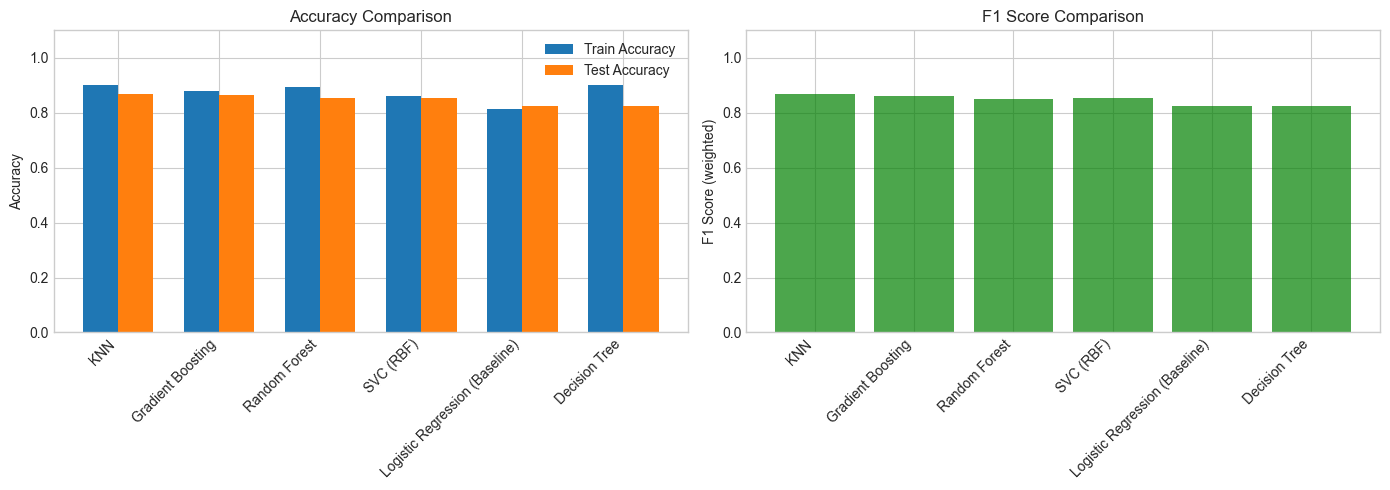

In [30]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.35

# Accuracy comparison
axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# F1 Score comparison
axes[1].bar(x, results_df['F1 (weighted)'], color='green', alpha=0.7)
axes[1].set_ylabel('F1 Score (weighted)')
axes[1].set_title('F1 Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

## Section 10.1: Hyperparameter Tuning with GridSearchCV

Rather than guessing hyperparameters, we use **GridSearchCV** to systematically search over a parameter grid using 5-fold cross-validation. This finds the combination that generalises best — directly addressing the train-test accuracy gap seen in the initial models.

In [31]:
# ── Tune Gradient Boosting ────────────────────────────────────────────────────
# max_depth capped at 4; subsample < 1.0 enables stochastic GB to reduce overfitting
gb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_leaf': [3, 5, 10],
    'subsample': [0.7, 0.8, 1.0]
}

gb_gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
gb_gs.fit(X_train_scaled, y_train)

print("Gradient Boosting — Best Parameters:", gb_gs.best_params_)
print(f"Best CV F1 (weighted): {gb_gs.best_score_:.4f}")

gb_tuned_results, gb_tuned_model, _ = evaluate_classifier(
    gb_gs.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test,
    "Gradient Boosting (Tuned)"
)
all_results.append(gb_tuned_results)
trained_models['Gradient Boosting (Tuned)'] = gb_tuned_model

print(f"\nGradient Boosting (Tuned) — Train: {gb_tuned_results['Train Accuracy']:.4f}  "
      f"Test: {gb_tuned_results['Test Accuracy']:.4f}  "
      f"Gap: {gb_tuned_results['Train Accuracy'] - gb_tuned_results['Test Accuracy']:.4f}")

Gradient Boosting — Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1 (weighted): 0.8617

Gradient Boosting (Tuned) — Train: 0.9932  Test: 0.9130  Gap: 0.0802


In [32]:
# ── Tune Random Forest ────────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 9],
    'min_samples_leaf': [3, 5, 10],
    'min_samples_split': [5, 10]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train_scaled, y_train)

print("Random Forest — Best Parameters:", rf_gs.best_params_)
print(f"Best CV F1 (weighted): {rf_gs.best_score_:.4f}")

rf_tuned_results, rf_tuned_model, _ = evaluate_classifier(
    rf_gs.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test,
    "Random Forest (Tuned)"
)
all_results.append(rf_tuned_results)
trained_models['Random Forest (Tuned)'] = rf_tuned_model

print(f"\nRandom Forest (Tuned)  — Train: {rf_tuned_results['Train Accuracy']:.4f}  "
      f"Test: {rf_tuned_results['Test Accuracy']:.4f}  "
      f"Gap: {rf_tuned_results['Train Accuracy'] - rf_tuned_results['Test Accuracy']:.4f}")

Random Forest — Best Parameters: {'max_depth': 9, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 (weighted): 0.8441

Random Forest (Tuned)  — Train: 0.9265  Test: 0.8750  Gap: 0.0515


In [33]:
# Final leaderboard — all models including tuned versions
results_df = pd.DataFrame(all_results).round(4).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df['Overfit Gap'] = (results_df['Train Accuracy'] - results_df['Test Accuracy']).round(4)

print("Full Model Leaderboard (sorted by Test Accuracy):")
results_df[['Model', 'Train Accuracy', 'Test Accuracy', 'F1 (weighted)', 'Overfit Gap']]

Full Model Leaderboard (sorted by Test Accuracy):


,Model,Train Accuracy,Test Accuracy,F1 (weighted),Overfit Gap
0,Gradient Boosting (Tuned),0.9932,0.9130,0.9128,0.0802
1,Random Forest (Tuned),0.9265,0.8750,0.8737,0.0515
2,KNN,0.8993,0.8696,0.8693,0.0297
3,Gradient Boosting,0.8776,0.8641,0.8627,0.0135
4,Random Forest,0.8925,0.8533,0.8517,0.0392
5,SVC (RBF),0.8612,0.8533,0.8520,0.0079
6,Logistic Regression (Baseline),0.8150,0.8261,0.8256,-0.0111
7,Decision Tree,0.9007,0.8261,0.8262,0.0746


## Section 11: Best Model Selection

In [34]:
# Identify best model (by test accuracy)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")
print(f"F1 Score: {results_df.iloc[0]['F1 (weighted)']:.4f}")

Best Model: Gradient Boosting (Tuned)
Test Accuracy: 0.9130
F1 Score: 0.9128


### Best Model Justification

*Explain why you chose this model:*

**Questions to consider:**
- Why this model over others?
- Is there significant overfitting?
- How does it compare to baseline?
- Which metrics did you prioritize and why?

**Your justification:**

[Write your justification here]

## Section 12: Best Model Analysis

In [35]:
# Get predictions from best model
y_pred = best_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.85      0.90        46
         Low       0.95      0.89      0.92        46
      Medium       0.88      0.96      0.92        92

    accuracy                           0.91       184
   macro avg       0.93      0.90      0.91       184
weighted avg       0.92      0.91      0.91       184



### Understanding the Classification Report

The classification report shows per-class metrics:

- **Precision:** Of all predictions for this class, what % were correct?
  - High precision = Few false positives
  - Example: "When the model predicts 'High', it's correct 85% of the time"

- **Recall:** Of all actual instances of this class, what % did we find?
  - High recall = Few false negatives
  - Example: "We correctly identified 90% of all actual 'High' cases"

- **F1-Score:** Harmonic mean of precision and recall (balanced measure)
  - Good when you need both precision and recall

- **Support:** Number of actual occurrences of each class in the test set

<Figure size 800x600 with 0 Axes>

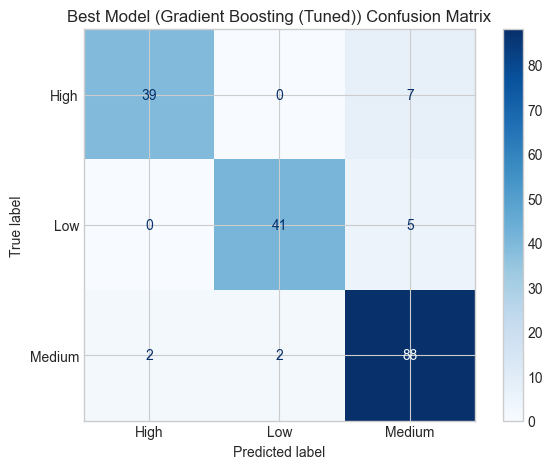

In [36]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title(f'Best Model ({best_model_name}) Confusion Matrix')
plt.tight_layout()
plt.show()

### Detailed Confusion Matrix Analysis

*Analyze the confusion matrix carefully:*

**For each class, describe:**
1. How many correct predictions (diagonal)?
2. What are the most common misclassifications?
3. Does the confusion make sense for your problem?

**Your analysis:**

[Write your detailed analysis here - e.g., "The model most often confuses Medium with High (X cases), which makes sense because..."]

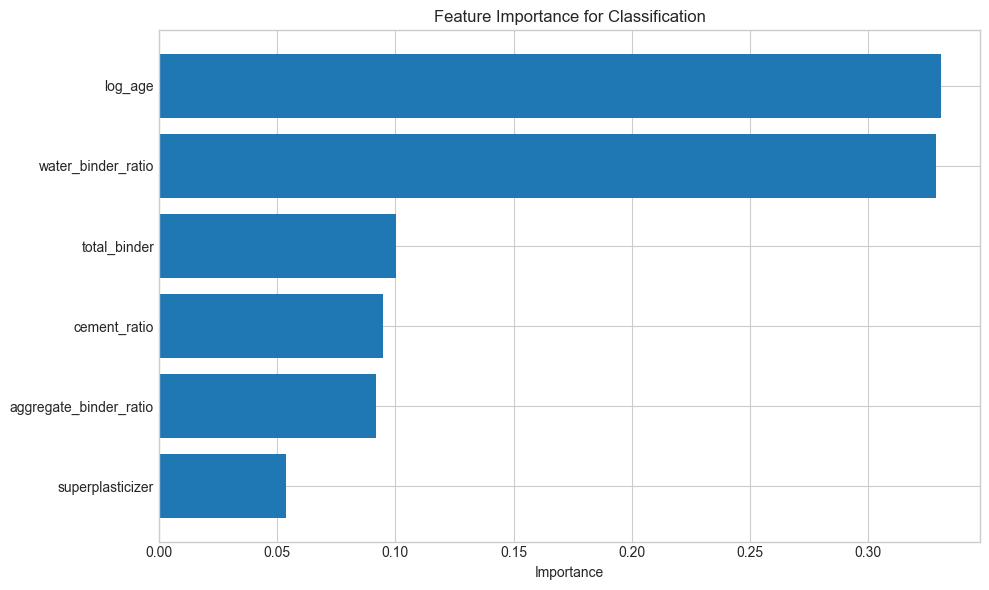


Top 5 most important features:
  log_age: 0.3307
  water_binder_ratio: 0.3287
  total_binder: 0.1003
  cement_ratio: 0.0946
  aggregate_binder_ratio: 0.0918


In [37]:
# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    for i, row in importance.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # For multi-class, coef_ has shape (n_classes, n_features)
    coef = best_model.coef_
    if len(coef.shape) > 1:
        # Average absolute importance across classes
        importance_vals = np.abs(coef).mean(axis=0)
    else:
        importance_vals = np.abs(coef)
    
    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance_vals
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'], importance['Importance'])
    plt.xlabel('Average Absolute Coefficient')
    plt.title('Feature Importance for Classification')
    plt.tight_layout()
    plt.show()

## Section 12.1: Learning Curves

Learning curves show how training and cross-validation accuracy change as more training data is used. They directly visualise the **bias-variance trade-off**:
- **Large gap** between train and CV curves → high variance (overfitting)
- **Both curves low and flat** → high bias (underfitting)
- **Curves converging** → model generalises well

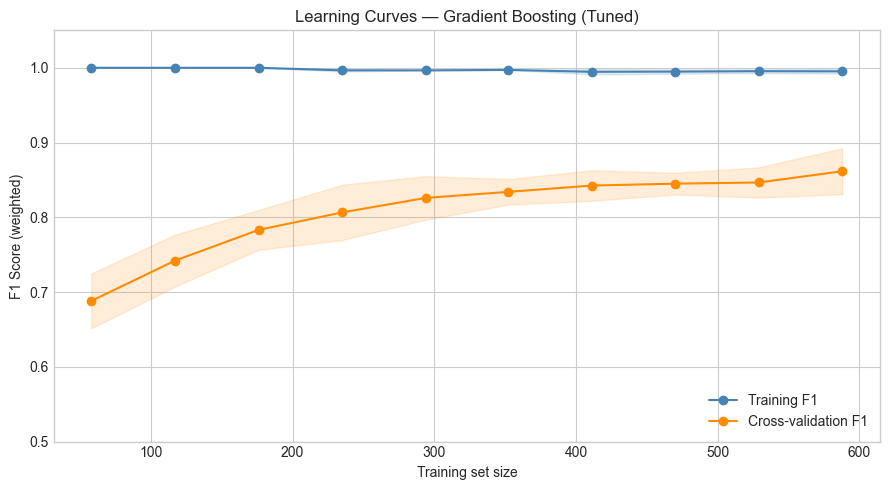

At full training size:
  Train F1:      0.9952 ± 0.0031
  CV F1:         0.8617 ± 0.0308
  Bias-Variance Gap: 0.1336


In [38]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1_weighted', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Cross-validation F1')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')

plt.xlabel('Training set size')
plt.ylabel('F1 Score (weighted)')
plt.title(f'Learning Curves — {best_model_name}')
plt.legend(loc='lower right')
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

final_gap = train_mean[-1] - val_mean[-1]
print(f"At full training size:")
print(f"  Train F1:      {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"  CV F1:         {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"  Bias-Variance Gap: {final_gap:.4f}")

## Section 12.2: ROC / AUC Curves (One-vs-Rest)

For multi-class classification, ROC curves are plotted using a **One-vs-Rest** strategy: each class is treated as the positive class in turn while the others are the negative class. The **AUC (Area Under the Curve)** summarises discriminability — 1.0 is perfect, 0.5 is random.

This goes beyond accuracy/F1 by showing performance at *every* decision threshold, not just the default 0.5.

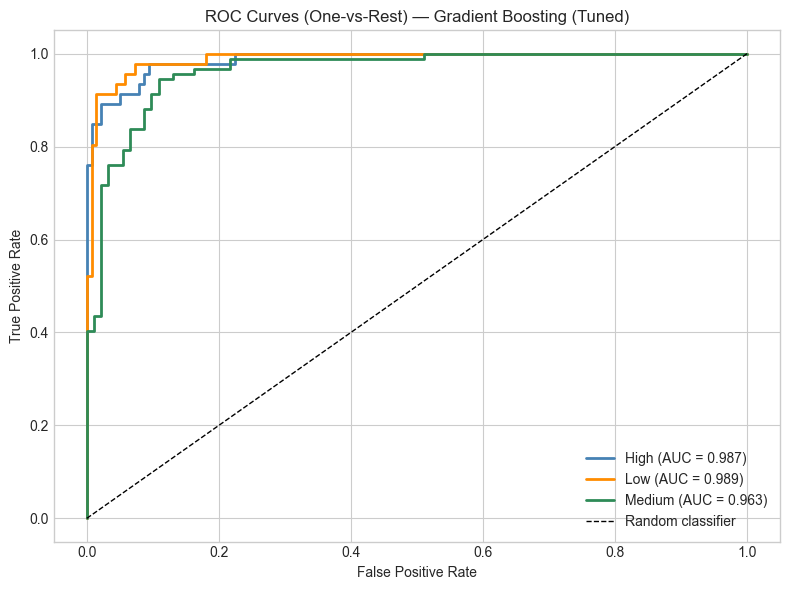

Macro-average AUC:    0.9796
Weighted-average AUC: 0.9756


In [39]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize test labels for one-vs-rest (order matches label_encoder.classes_)
class_order = list(range(len(label_encoder.classes_)))
y_test_bin = label_binarize(y_test, classes=class_order)

# Get predicted probabilities (requires probability=True or a tree-based model)
if hasattr(best_model, 'predict_proba'):
    y_prob = best_model.predict_proba(X_test_scaled)
else:
    raise ValueError("Best model does not support predict_proba.")

colors = ['steelblue', 'darkorange', 'seagreen']
plt.figure(figsize=(8, 6))

for i, (cls_name, color) in enumerate(zip(label_encoder.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves (One-vs-Rest) — {best_model_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Macro-average AUC
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
weighted_auc = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')
print(f"Macro-average AUC:    {macro_auc:.4f}")
print(f"Weighted-average AUC: {weighted_auc:.4f}")

## Section 13: Model Iteration Reflection

*Reflect on your modeling process:*

**1. How did your models evolve from baseline to best?**

[Describe the progression and what you learned]

**2. What surprised you about the results?**

[Any unexpected findings?]

**3. If you had more time, what would you try next?**

[Future improvements to explore]

## Section 14: Save Model and Artifacts

In [40]:
# Save the best classification model
model_path = '../models/classification_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on SELECTED features)
scaler_path = '../models/classification_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the label encoder
encoder_path = '../models/label_encoder.pkl'
joblib.dump(label_encoder, encoder_path)
print(f"Label encoder saved to {encoder_path}")

# Save feature names (SELECTED_FEATURES)
features_path = '../models/classification_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

# Save binning info (for reference in Streamlit app)
binning_info = {
    'bins': bins,
    'labels': labels,
    'original_target': ORIGINAL_TARGET
}
binning_path = '../models/binning_info.pkl'
joblib.dump(binning_info, binning_path)
print(f"Binning info saved to {binning_path}")

Model saved to ../models/classification_model.pkl
Scaler saved to ../models/classification_scaler.pkl
Label encoder saved to ../models/label_encoder.pkl
Features saved to ../models/classification_features.pkl
Binning info saved to ../models/binning_info.pkl


In [41]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)

# Test prediction
test_sample = X_test.iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)
test_pred_label = loaded_encoder.inverse_transform(test_pred)

print(f"\nModel verification:")
print(f"Sample input: {test_sample.values[0][:3]}...")
print(f"Predicted class: {test_pred_label[0]}")
print(f"Actual class: {loaded_encoder.inverse_transform([y_test[0]])[0]}")
print("\nModel saved and verified successfully!")


Model verification:
Sample input: [  2.07944154   0.66192171 281.        ]...
Predicted class: Low
Actual class: Low

Model saved and verified successfully!


---

## Summary

### What You Accomplished
- [ ] Created binned target variable with justification
- [ ] Verified class balance
- [ ] Used consistent features (same as regression or justified different)
- [ ] Split data with stratification
- [ ] Performed cross-validation
- [ ] Built baseline classifier
- [ ] Tried multiple classifier types
- [ ] Compared and selected best model
- [ ] Analyzed model with confusion matrix and classification report
- [ ] Saved model, scaler, encoder, and binning info

### Key Results

**Best Model:** [Model name]

**Test Accuracy:** [Value]

**F1 Score:** [Value]

**Improvement over baseline:** [Percentage or description]

### Comparison to Regression

*How does classification performance relate to your regression results?*

[Write your comparison here - consider: Are the same features important? Does predicting categories work better/worse than predicting exact values for your problem?]

---

## Next Steps

Move on to building your **Streamlit app** to deploy both models!

You now have saved:
- `regression_model.pkl` and `regression_scaler.pkl`
- `classification_model.pkl`, `classification_scaler.pkl`, and `label_encoder.pkl`

The Streamlit starter code in `app/app.py` will load these files.

---

## Checkpoint 4 Submission Instructions

You've completed the classification model. Time to submit!

### Step 1: Save and Close
Make sure this notebook is saved and all cells have been run.

### Step 2: Commit Your Work
```bash
git add .
git commit -m "Complete classification model - Checkpoint 4"
git push
```

### Step 3: Submit to Canvas
1. Go to Canvas
2. Find the **Checkpoint 4: Classification Model** assignment
3. Submit the link to your GitHub repository

### What Gets Graded
- Binning justification and implementation
- Feature consistency (same as regression or justified different)
- Model comparison and selection reasoning
- Confusion matrix interpretation
- Classification report analysis
- All written reflections completed

---